# 📊 Exploratory Data Analysis (EDA) — Airbnb NYC 2019

## Problem Statement
Analyze the Airbnb NYC dataset to help users identify the most suitable listings based on **pricing, neighborhood, reviews, availability, and stay preferences**, enabling better booking decisions.

---

### Notebook Outline
1. Data Overview
2. Column Selection
3. Univariate Analysis
4. Bivariate Analysis
5. Multivariate Analysis
6. Final Business Insights

---
## 🔹 Step 1: Data Overview
We begin by loading the cleaned dataset and inspecting its structure, data types, missing values, and basic statistics.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


In [ ]:

df = pd.read_csv('../data/processed/processed_AB_NYC_2019 (5).csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 45923 rows × 16 columns


,id,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_per_person
0,2539,Clean & quiet apt home by the park,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19 00:00:00,0.21,6,365,74.50
1,2595,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21 00:00:00,0.38,2,355,112.50
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365,37.50
3,3831,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05 00:00:00,4.64,1,194,44.50
4,5022,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19 00:00:00,0.10,1,0,7.27


In [ ]:

df.dtypes

id                                  int64
name                               object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
price_per_person                  float64
dtype: object

In [ ]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Percentage (%)


In [ ]:

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,45923.0,NaN,NaN,NaN,18898529.649239,10919223.440997,2539.0,9436180.0,19525675.0,28912563.0,36487245.0
name,45923,44993,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_name,45923,11009,Michael,383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,45923,5,Manhattan,19506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,45923,219,Williamsburg,3732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,45923.0,NaN,NaN,NaN,40.728488,0.055331,40.49979,40.689235,40.72177,40.76339,40.91306
longitude,45923.0,NaN,NaN,NaN,-73.950733,0.046471,-74.24442,-73.981925,-73.95437,-73.934315,-73.71299
room_type,45923,3,Entire home/apt,22789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,45923.0,NaN,NaN,NaN,119.97032,68.150148,0.0,65.0,100.0,159.0,334.0
minimum_nights,45923.0,NaN,NaN,NaN,6.93807,19.857823,1.0,1.0,2.0,5.0,1250.0


### 📝 Observations
- The dataset contains ~46,000 listings across New York City.
- Key numerical columns include `price`, `minimum_nights`, `number_of_reviews`, `availability_365`, and `reviews_per_month`.
- Categorical columns like `neighbourhood_group` and `room_type` will be central to our analysis.

---
## 🔹 Step 2: Column Selection

We drop columns that do **not** contribute to booking decisions (IDs, URLs, host names, coordinates, etc.) and retain only **actionable** features.

| Kept Column | Reason |
|---|---|
| `price` | Primary decision factor for travellers |
| `neighbourhood_group` | Borough-level location preference |
| `neighbourhood` | Granular location insight |
| `room_type` | Accommodation style preference |
| `number_of_reviews` | Proxy for popularity / trust |
| `reviews_per_month` | Engagement frequency |
| `availability_365` | Supply-side indicator |
| `minimum_nights` | Stay-length requirement |

In [ ]:

cols = ['price', 'neighbourhood_group', 'neighbourhood', 'room_type',
        'number_of_reviews', 'reviews_per_month', 'availability_365', 'minimum_nights']

df_eda = df[cols].copy()
print(f'Selected {len(cols)} columns for EDA.')
df_eda.head()

Selected 8 columns for EDA.


,price,neighbourhood_group,neighbourhood,room_type,number_of_reviews,reviews_per_month,availability_365,minimum_nights
0,149,Brooklyn,Kensington,Private room,9,0.21,365,1
1,225,Manhattan,Midtown,Entire home/apt,45,0.38,355,1
2,150,Manhattan,Harlem,Private room,0,0.00,365,3
3,89,Brooklyn,Clinton Hill,Entire home/apt,270,4.64,194,1
4,80,Manhattan,East Harlem,Entire home/apt,9,0.10,0,10


---
## 🔹 Step 3: Univariate Analysis
Examine each variable individually to understand its distribution, spread, and outliers.

### 3.1 Numerical Columns

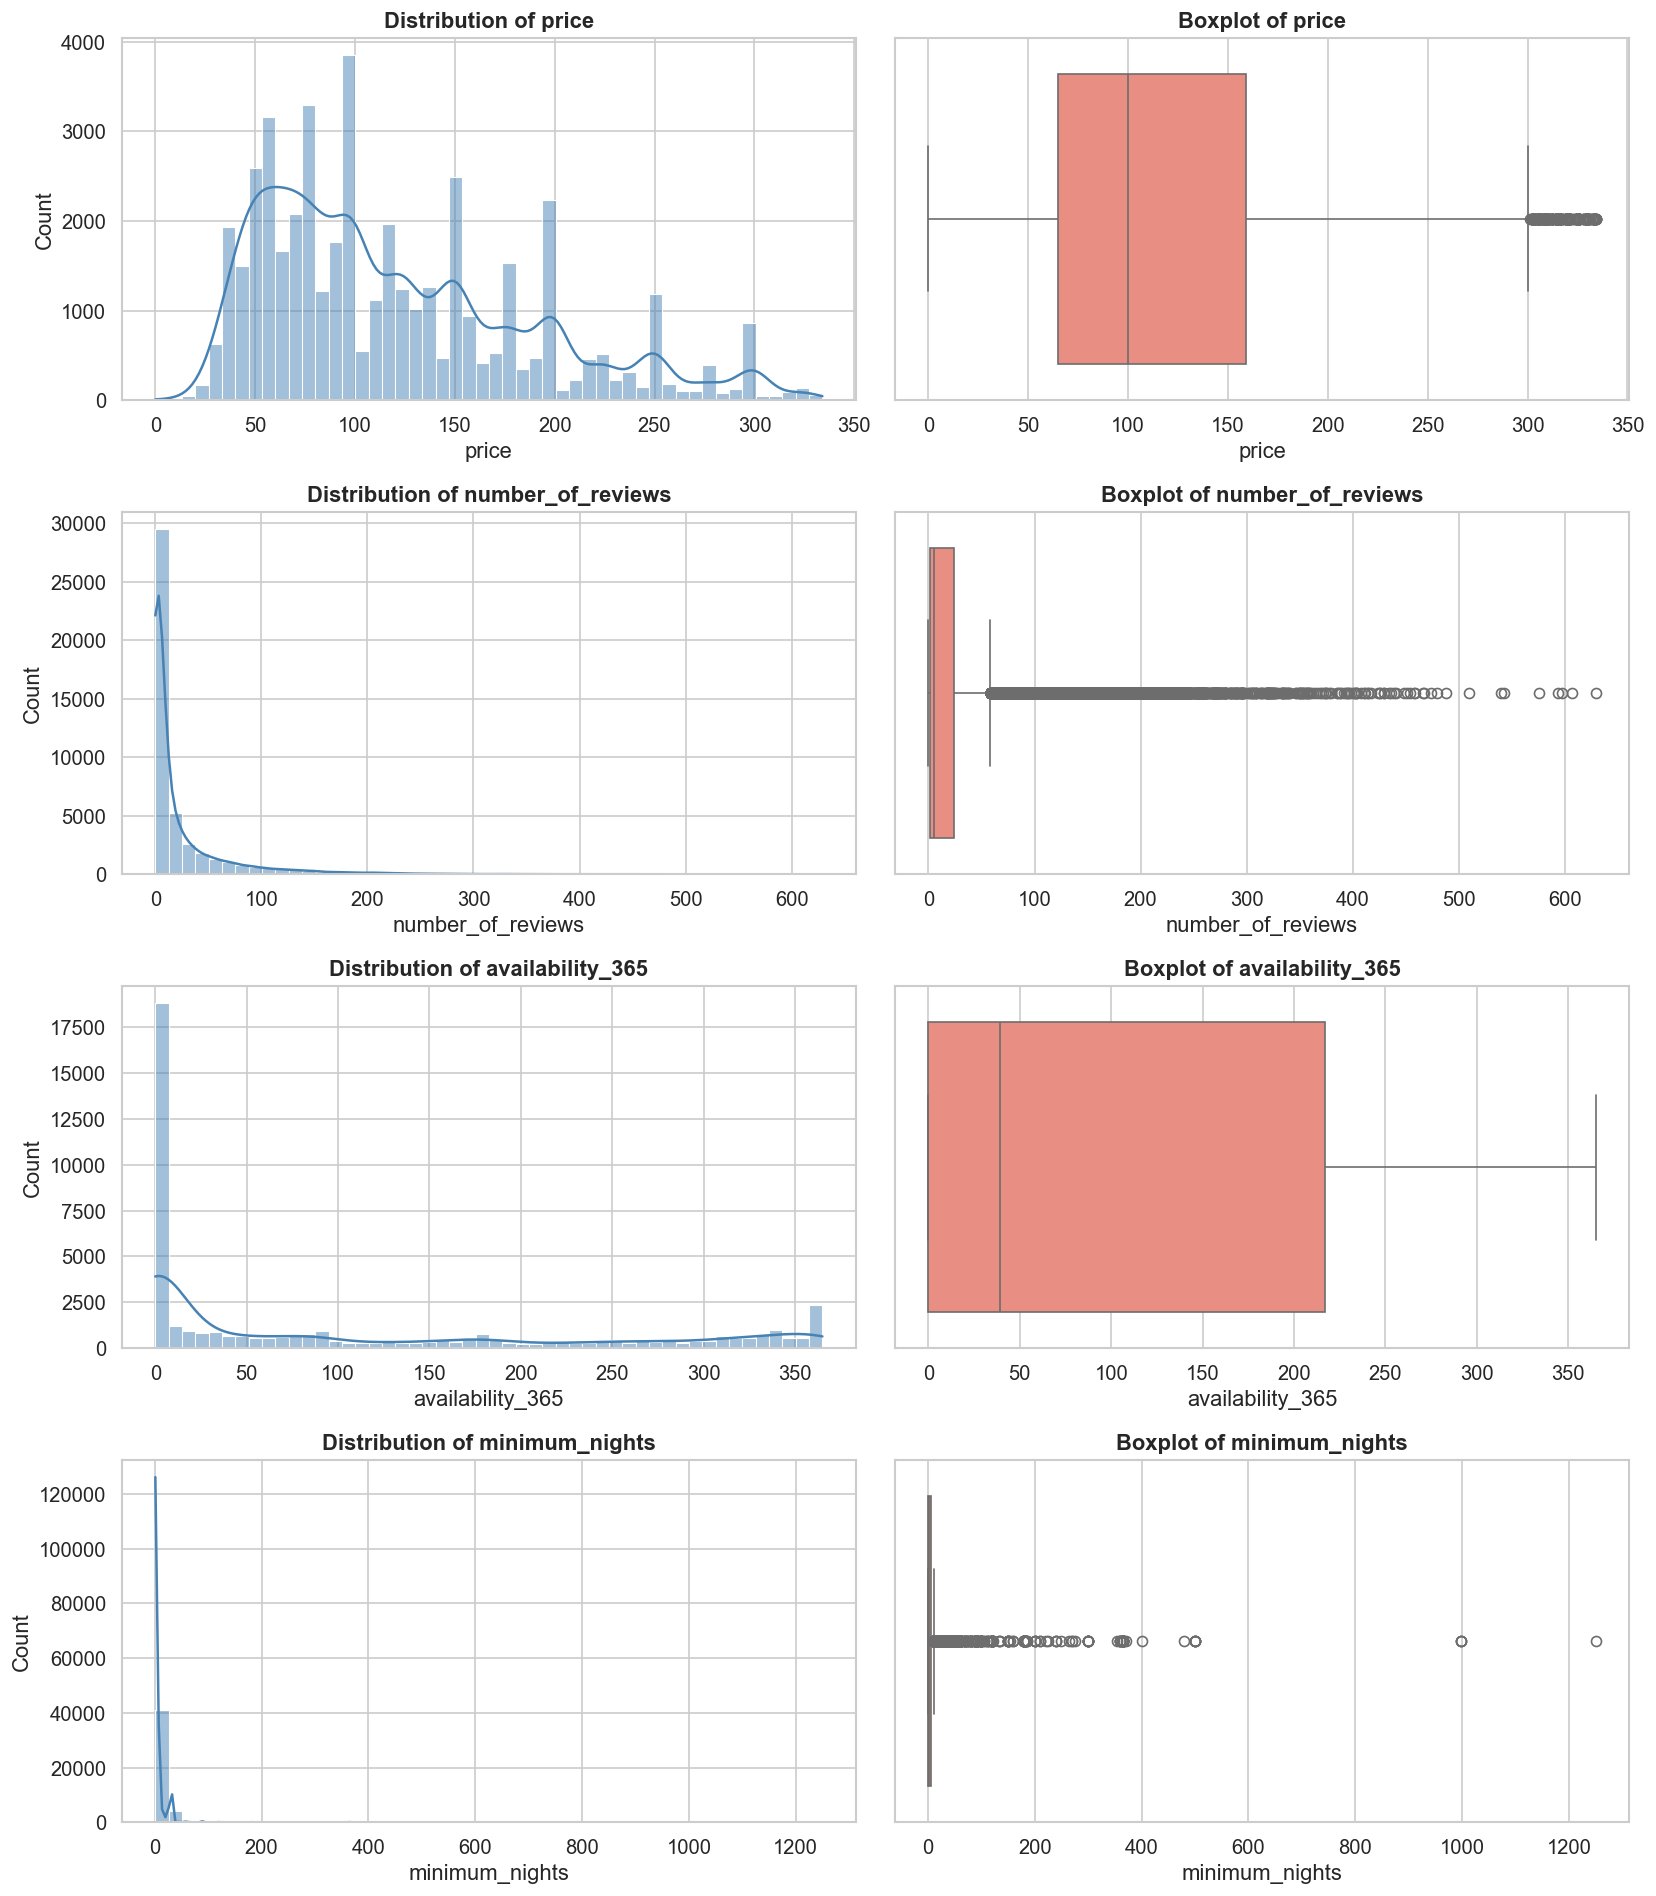

In [ ]:
num_cols = ['price', 'number_of_reviews', 'availability_365', 'minimum_nights']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))

for i, col in enumerate(num_cols):

    sns.histplot(df_eda[col], kde=True, ax=axes[i, 0], color='steelblue', bins=50)
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i, 0].set_xlabel(col)


    sns.boxplot(x=df_eda[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ── Skewness Summary ──
for col in num_cols:
    skew_val = df_eda[col].skew()
    print(f'{col:25s}  Skewness = {skew_val:>8.2f}  →  {"Highly right-skewed" if skew_val > 2 else "Moderately skewed" if skew_val > 1 else "Approximately symmetric"}')

price                      Skewness =     0.92  →  Approximately symmetric
number_of_reviews          Skewness =     3.63  →  Highly right-skewed
availability_365           Skewness =     0.81  →  Approximately symmetric
minimum_nights             Skewness =    21.93  →  Highly right-skewed


### 📝 Insights — Numerical Univariate
- **Price** is heavily right-skewed — most listings are budget-friendly, but luxury outliers push the tail.
- **Number of reviews** is also right-skewed — a few listings are extremely popular while most have few reviews.
- **Availability** shows a bimodal pattern: listings are either almost always available or rarely available.
- **Minimum nights** has extreme outliers (some require 365+ nights), which are likely long-term rentals.

### 3.2 Categorical Columns

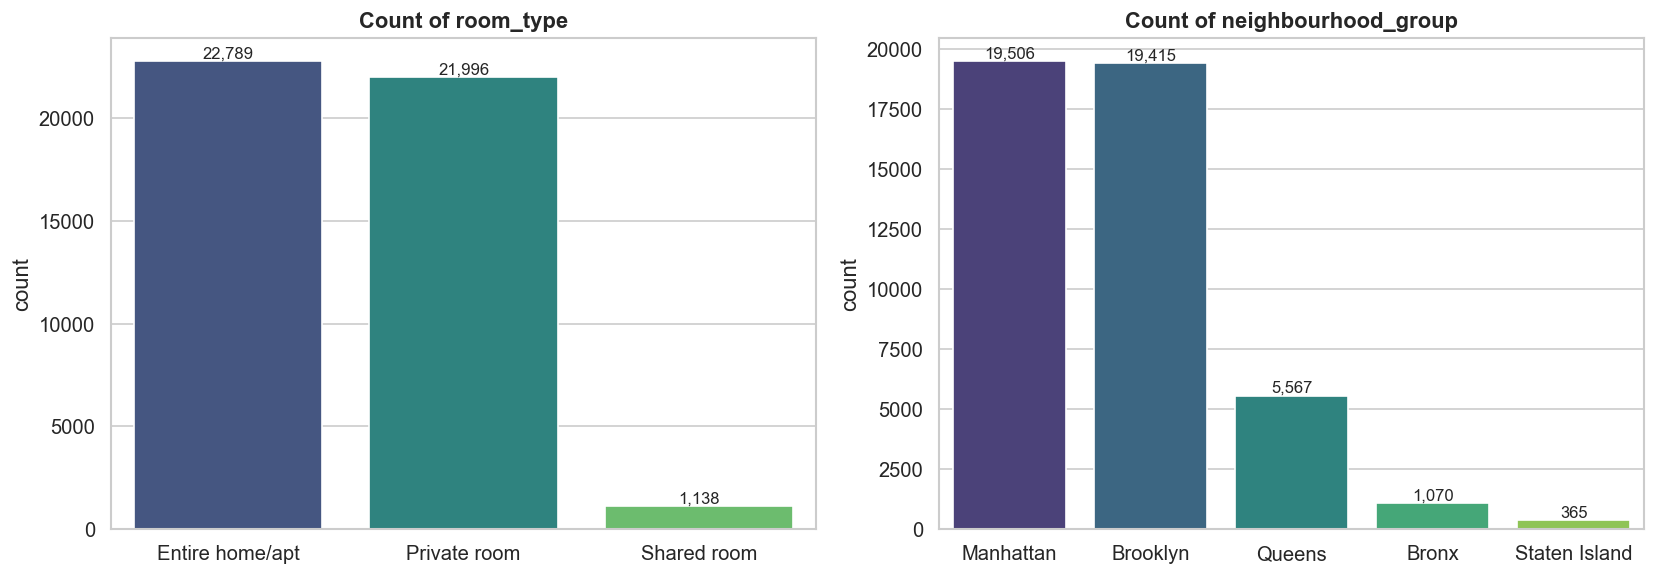

In [ ]:
cat_cols = ['room_type', 'neighbourhood_group']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    order = df_eda[col].value_counts().index
    sns.countplot(data=df_eda, x=col, order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Count of {col}', fontweight='bold')
    axes[i].set_xlabel('')

    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height()):,}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

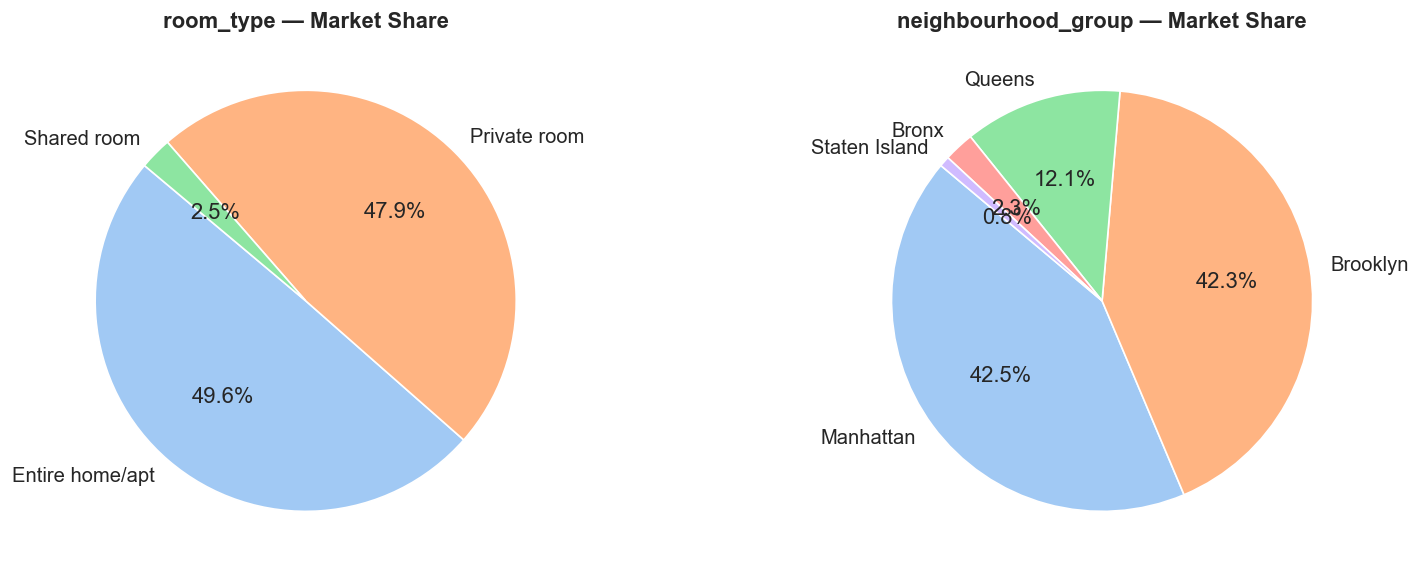

In [11]:
# ── Pie Charts ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    counts = df_eda[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%',
                startangle=140, colors=sns.color_palette('pastel'))
    axes[i].set_title(f'{col} — Market Share', fontweight='bold')

plt.tight_layout()
plt.show()

### 📝 Insights — Categorical Univariate
- **Entire home/apt** and **Private room** dominate the market, with shared rooms being a niche segment.
- **Manhattan** and **Brooklyn** together account for the majority of listings, reflecting NYC's tourism hotspots.
- Staten Island has the fewest listings, indicating lower tourist demand.

---
## 🔹 Step 4: Bivariate Analysis
Explore relationships between two variables.

### 4.1 Numerical vs Numerical

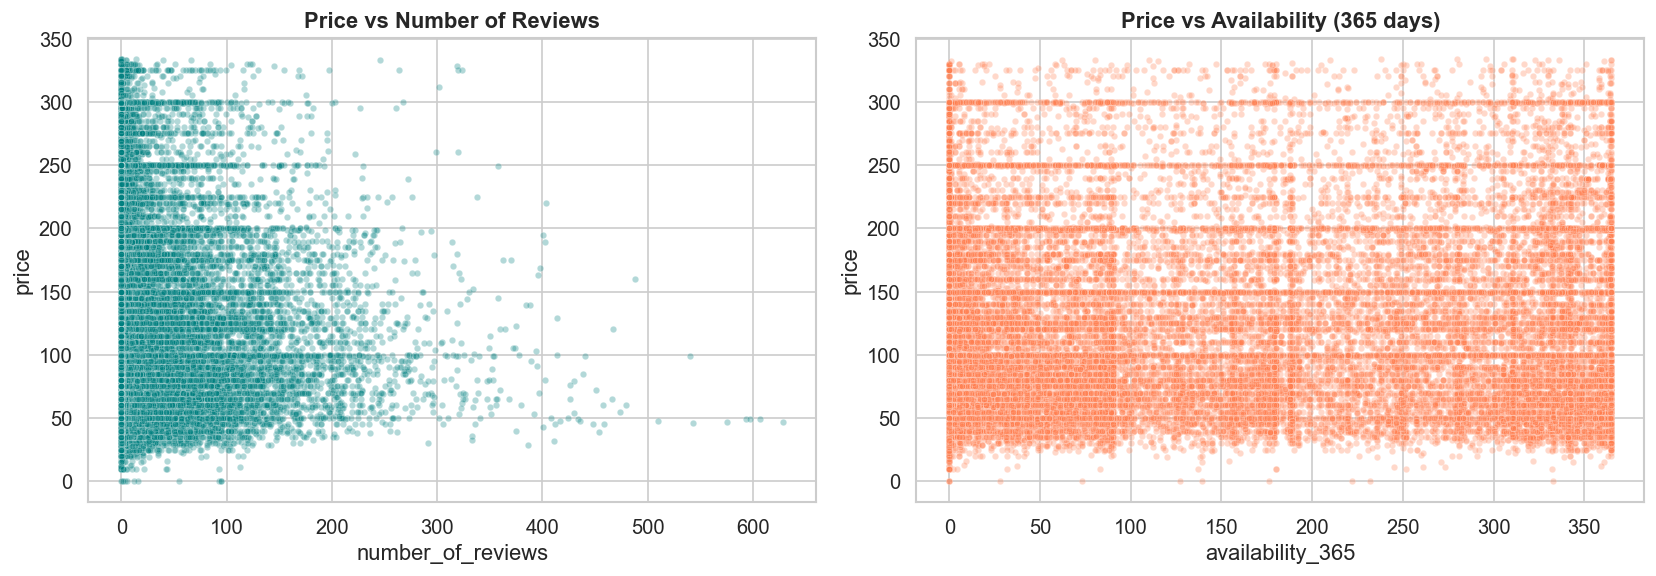

In [ ]:
# Price vs No. of Reviews 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter extreme prices for cleaner visualization
plot_df = df_eda[df_eda['price'] <= 1000]

sns.scatterplot(data=plot_df, x='number_of_reviews', y='price',
                alpha=0.3, ax=axes[0], color='teal', s=15)
axes[0].set_title('Price vs Number of Reviews', fontweight='bold')

sns.scatterplot(data=plot_df, x='availability_365', y='price',
                alpha=0.3, ax=axes[1], color='coral', s=15)
axes[1].set_title('Price vs Availability (365 days)', fontweight='bold')

plt.tight_layout()
plt.show()

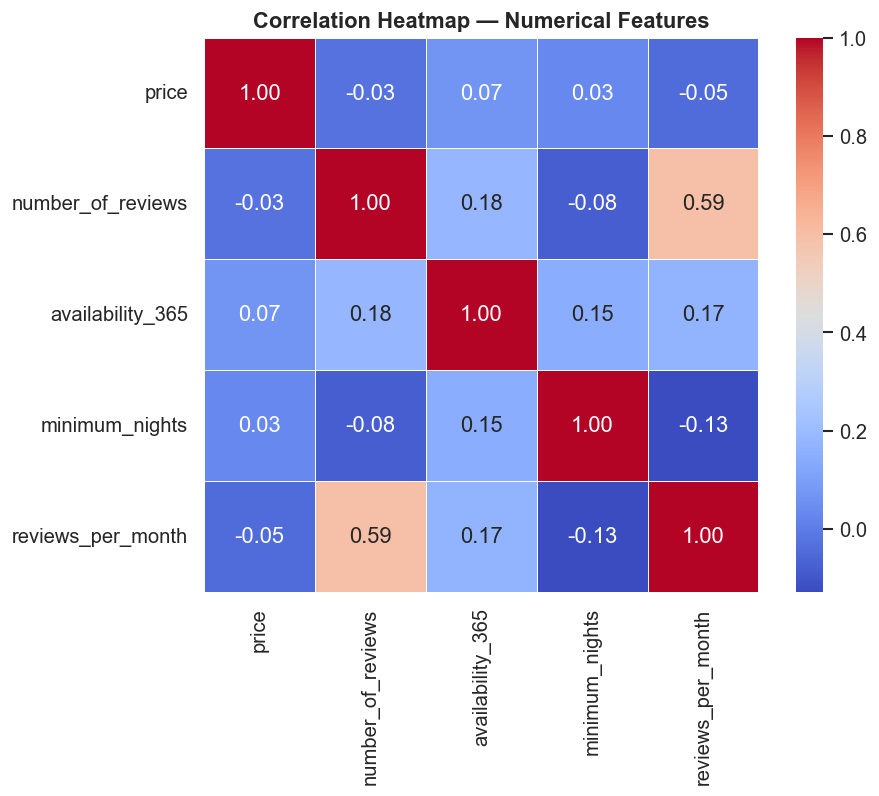

In [ ]:
# corr heat map numeric cols
corr = df_eda[num_cols + ['reviews_per_month']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numerical Features', fontweight='bold')
plt.show()

### 📝 Insights — Numerical vs Numerical
- **Price and reviews** show a weak negative correlation — cheaper listings tend to receive more reviews (higher booking frequency).
- **Price and availability** have almost no linear relationship, but the scatter reveals that ultra-expensive listings often have high availability (low demand).
- **Reviews per month** and **number of reviews** are positively correlated, as expected.

### 4.2 Categorical vs Numerical

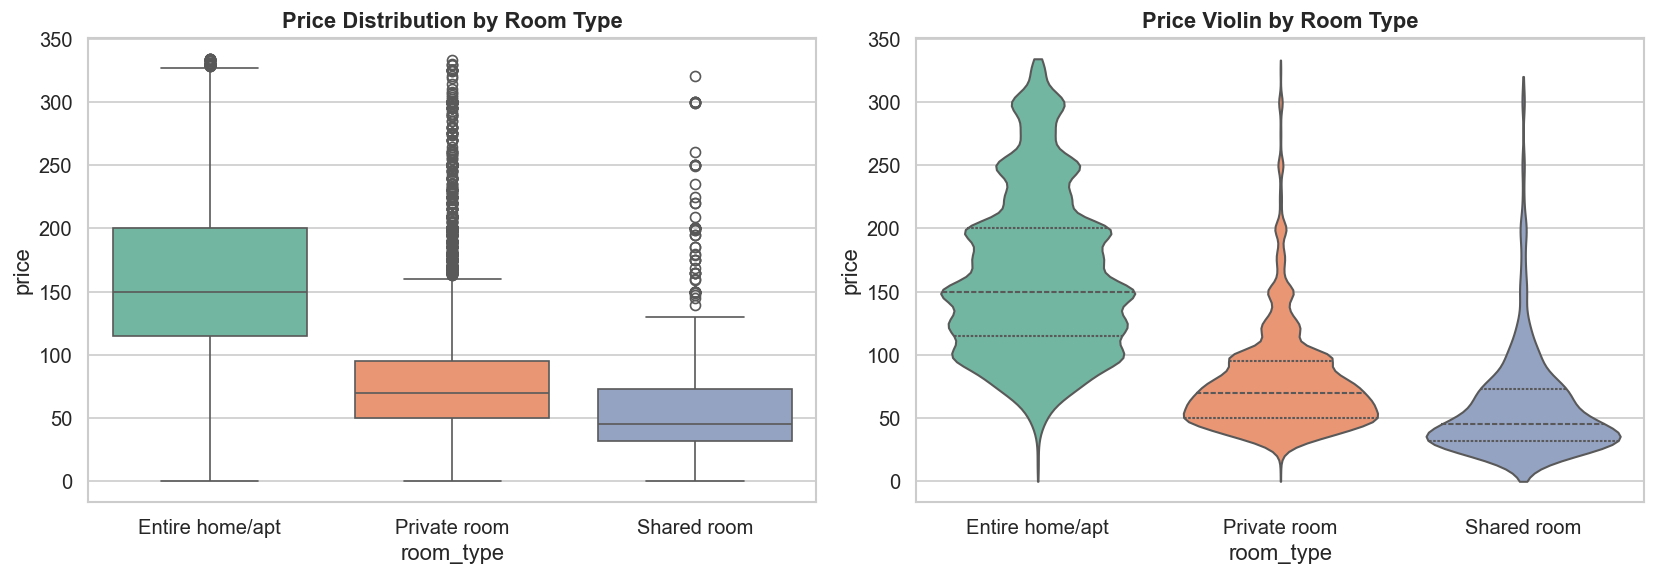

In [ ]:
#room Type vs Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x='room_type', y='price', ax=axes[0],
            palette='Set2', order=['Entire home/apt', 'Private room', 'Shared room'])
axes[0].set_title('Price Distribution by Room Type', fontweight='bold')

sns.violinplot(data=plot_df, x='room_type', y='price', ax=axes[1],
               palette='Set2', order=['Entire home/apt', 'Private room', 'Shared room'],
               inner='quartile', cut=0)
axes[1].set_title('Price Violin by Room Type', fontweight='bold')

plt.tight_layout()
plt.show()

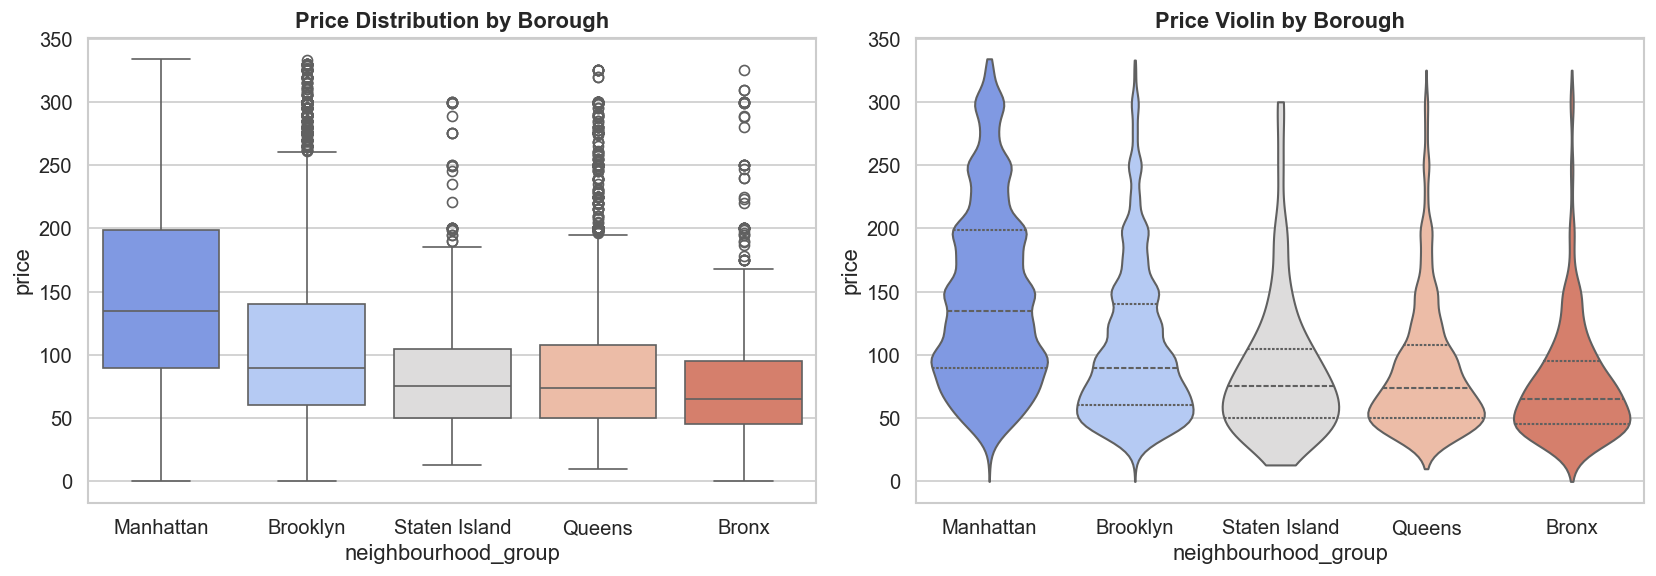

In [ ]:
# neighbourhood Group vs Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_ng = plot_df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index

sns.boxplot(data=plot_df, x='neighbourhood_group', y='price', ax=axes[0],
            palette='coolwarm', order=order_ng)
axes[0].set_title('Price Distribution by Borough', fontweight='bold')

sns.violinplot(data=plot_df, x='neighbourhood_group', y='price', ax=axes[1],
               palette='coolwarm', order=order_ng, inner='quartile', cut=0)
axes[1].set_title('Price Violin by Borough', fontweight='bold')

plt.tight_layout()
plt.show()

### 📝 Insights — Categorical vs Numerical
- **Entire homes/apartments** are the most expensive room type, while shared rooms are the cheapest.
- **Manhattan** has the highest median price, followed by Brooklyn. The Bronx and Staten Island are more budget-friendly.
- The violin plots reveal that private rooms have a tight price concentration, making them predictable for budget travellers.

### 4.3 Categorical vs Categorical

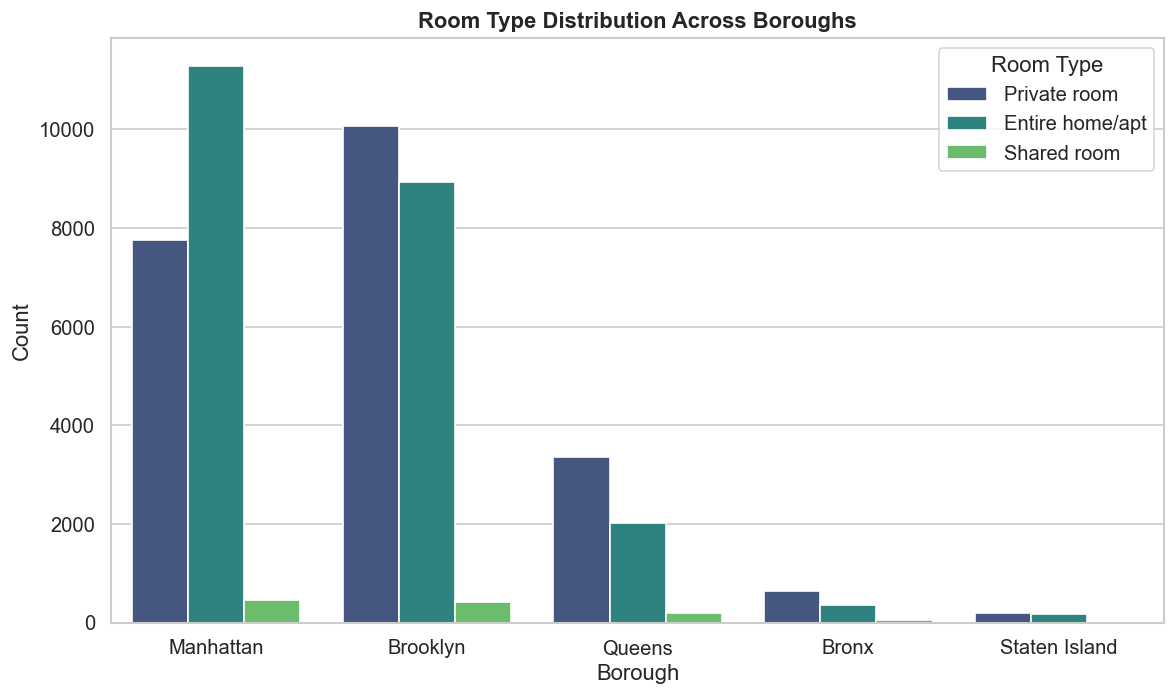

In [ ]:
# room Type vs Neighbourhood Group
plt.figure(figsize=(10, 6))
sns.countplot(data=df_eda, x='neighbourhood_group', hue='room_type',
              palette='viridis',
              order=df_eda['neighbourhood_group'].value_counts().index)
plt.title('Room Type Distribution Across Boroughs', fontweight='bold')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

In [ ]:

ct = pd.crosstab(df_eda['neighbourhood_group'], df_eda['room_type'], normalize='index') * 100
ct.round(1)

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,33.9,60.6,5.5
Brooklyn,46.1,51.8,2.1
Manhattan,57.9,39.7,2.4
Queens,36.3,60.2,3.5
Staten Island,46.0,51.5,2.5


### 📝 Insights — Categorical vs Categorical
- **Manhattan** is dominated by entire homes/apartments, reflecting its premium positioning.
- **Brooklyn** and the **Bronx** have a higher share of private rooms, catering to budget-conscious visitors.
- **Shared rooms** are uniformly rare across all boroughs.

---
## 🔹 Step 5: Multivariate Analysis
Explore interactions among multiple variables simultaneously.

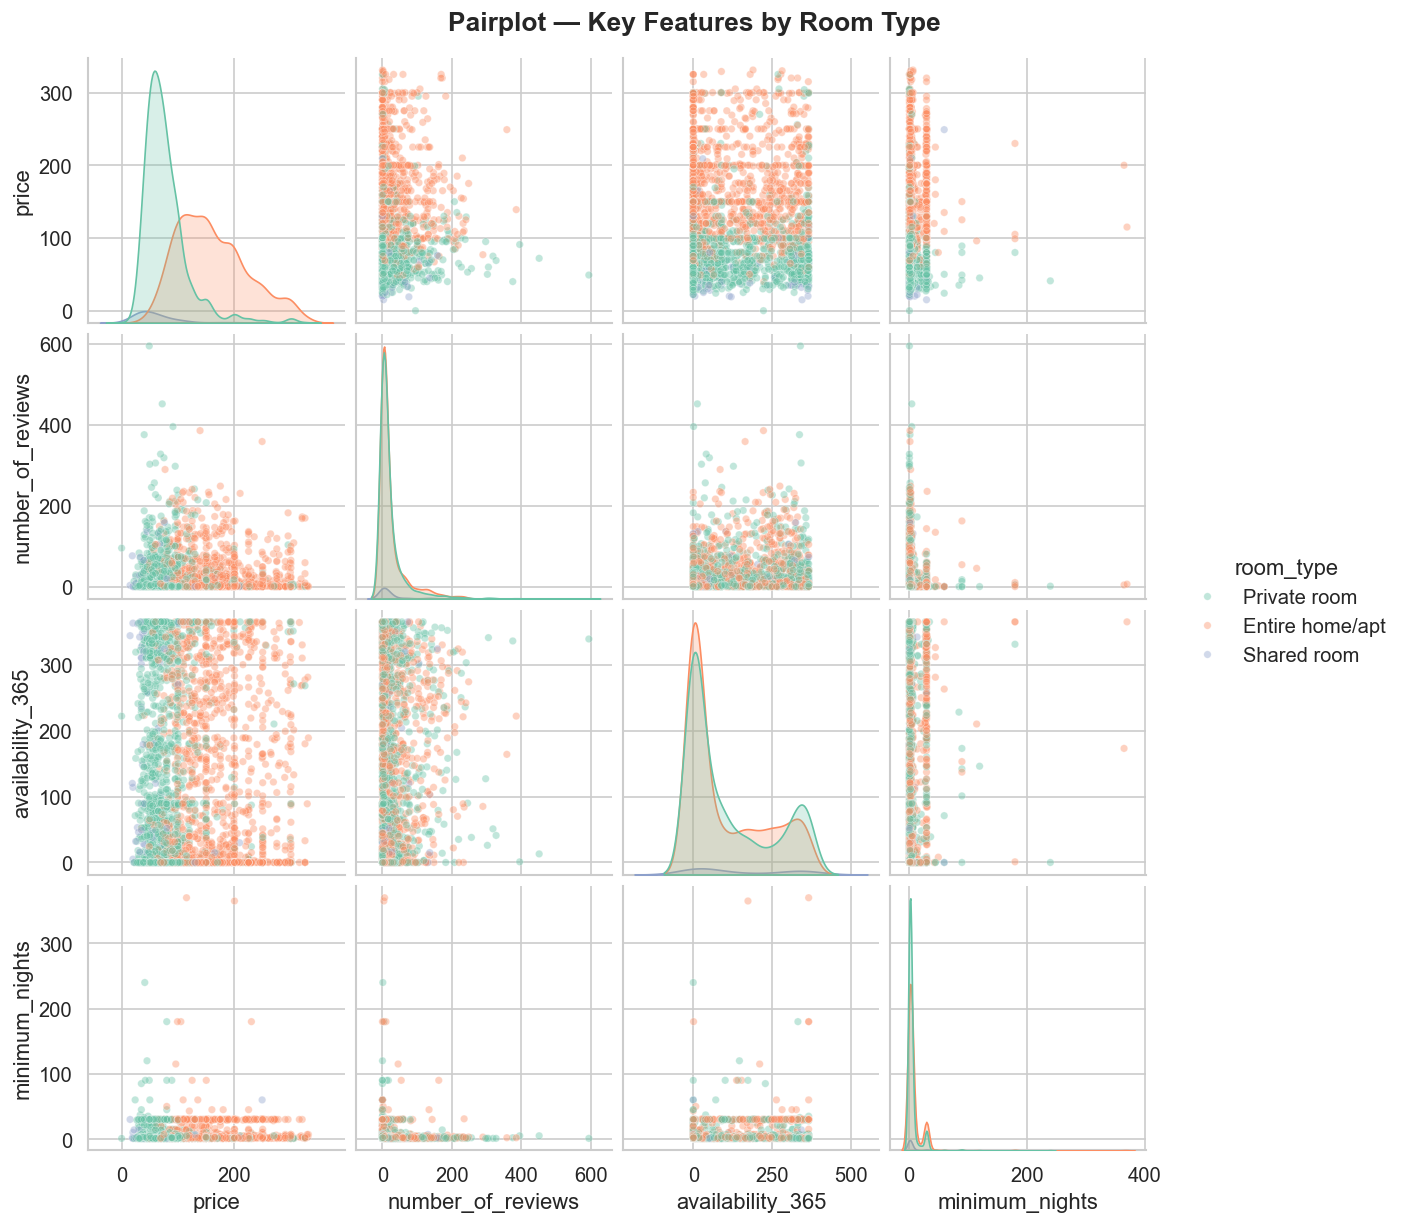

In [ ]:

pair_cols = ['price', 'number_of_reviews', 'availability_365', 'minimum_nights', 'room_type']
sample = df_eda[df_eda['price'] <= 500][pair_cols].sample(3000, random_state=42)

sns.pairplot(sample, hue='room_type', palette='Set2',
             diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20})
plt.suptitle('Pairplot — Key Features by Room Type', y=1.02, fontweight='bold')
plt.show()

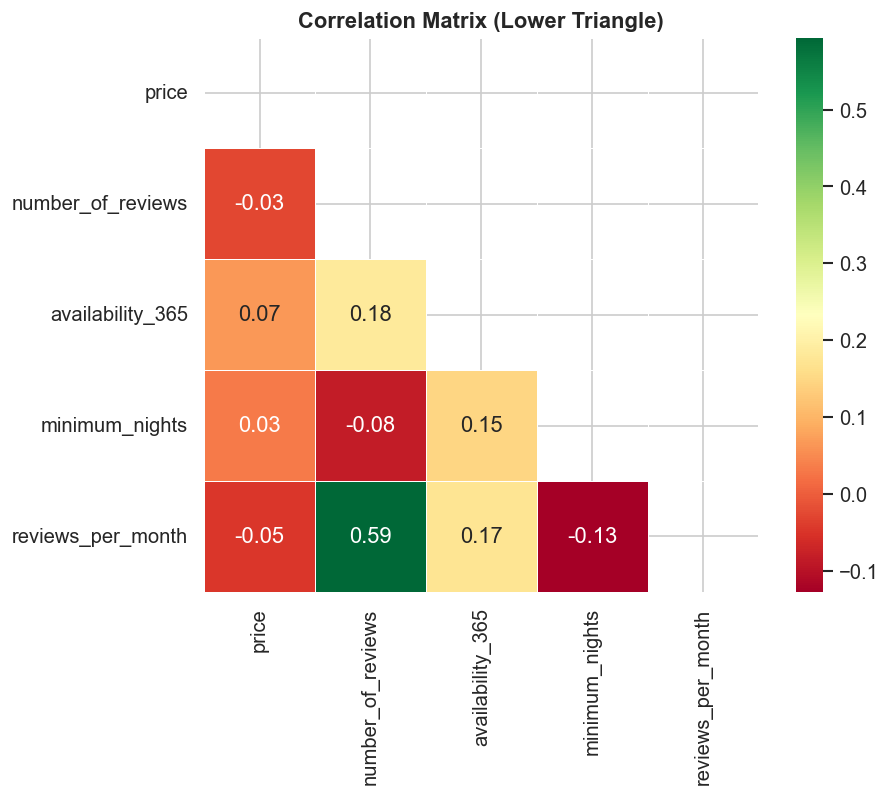

In [ ]:

full_corr = df_eda[num_cols + ['reviews_per_month']].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(full_corr, dtype=bool))
sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Matrix (Lower Triangle)', fontweight='bold')
plt.show()

### 📝 Insights — Multivariate
- The pairplot confirms that **entire homes cluster at higher prices** while private and shared rooms concentrate at the lower end.
- **No single numerical feature strongly predicts price**, suggesting that location and room type are the dominant drivers.
- Listings with very high minimum-night requirements are scattered — they likely serve a niche (corporate / long-term) market.

---
## 🔹 Step 6: Final EDA Insights

Below are **10 actionable business insights** derived from this analysis:

1. **Entire homes dominate Manhattan and command the highest prices** — travellers seeking luxury or privacy should budget accordingly.

2. **Private rooms in Brooklyn offer the best value-for-money** — budget travellers get access to a vibrant borough at significantly lower prices.

3. **Shared rooms are a niche segment (<3 % of listings)** — they are the cheapest option but scarce and concentrated in Manhattan and Brooklyn.

4. **Cheaper listings receive more reviews** — affordable stays drive higher booking volumes, indicating strong demand at the budget end.

5. **High-availability listings tend to have lower pricing** — hosts who keep prices competitive maintain near-full-year availability to attract bookings.

6. **Manhattan's median price is roughly 1.5× Brooklyn's** — the borough premium is substantial and consistent across room types.

7. **Extreme minimum-night requirements (30+ days) indicate long-term rentals** — these listings operate under different market dynamics and should be filtered for short-stay analysis.

8. **Staten Island and the Bronx are underserved markets** — low listing counts may signal an opportunity for new hosts or a lack of tourist demand.

9. **Reviews per month is a reliable engagement proxy** — it correlates well with total reviews and can help identify consistently popular listings.

10. **No single numerical feature strongly predicts price** — pricing is primarily driven by **room type** and **location (borough/neighbourhood)**, confirming these as the most important filters for travellers.

---
*Notebook prepared by Section A — Group 18 | Airbnb NYC Analysis Project*